# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load Dataset

In [6]:
df = pd.read_csv("cms_medicare_claims.csv", encoding="latin1", engine='python', on_bad_lines='skip')

df.head()

,provider_id,hospital_name,city,state,state_fips,zip_code,state_abbr,ruca_code,area_type,drg_code,procedure,total_discharges,avg_charge,avg_total_payment,avg_medicare_payment
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,14,663764.3571,120219.92860,115544.142900
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,26,180980.8846,37321.03846,35261.807690
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,12,105824.3333,26936.66667,25048.916670
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,16,242539.5000,34745.37500,32438.625000
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,11,122741.1818,14999.81818,9579.363636


In [9]:
df.shape

(56852, 15)

In [10]:
df.columns

Index(['provider_id', 'hospital_name', 'city', 'state', 'state_fips',
       'zip_code', 'state_abbr', 'ruca_code', 'area_type', 'drg_code',
       'procedure', 'total_discharges', 'avg_charge', 'avg_total_payment',
       'avg_medicare_payment'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56852 entries, 0 to 56851
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   provider_id           56852 non-null  int64  
 1   hospital_name         56852 non-null  object 
 2   city                  56852 non-null  object 
 3   state                 56852 non-null  object 
 4   state_fips            56852 non-null  int64  
 5   zip_code              56852 non-null  int64  
 6   state_abbr            56852 non-null  object 
 7   ruca_code             56848 non-null  float64
 8   area_type             56848 non-null  object 
 9   drg_code              56852 non-null  int64  
 10  procedure             56852 non-null  object 
 11  total_discharges      56852 non-null  int64  
 12  avg_charge            56852 non-null  float64
 13  avg_total_payment     56852 non-null  float64
 14  avg_medicare_payment  56852 non-null  float64
dtypes: float64(4), int6

In [12]:
df.describe()

,provider_id,state_fips,zip_code,ruca_code,drg_code,total_discharges,avg_charge,avg_total_payment,avg_medicare_payment
count,56852.000000,56852.000000,56852.000000,56848.000000,56852.000000,56852.000000,5.685200e+04,56852.000000,56852.000000
mean,92567.863030,11.126979,58152.821765,1.531275,421.251390,33.884191,1.040949e+05,18520.104980,15429.703738
std,46602.144509,5.507146,26325.046078,4.746210,250.614225,51.050627,1.302637e+05,21841.848479,18968.957232
min,10001.000000,1.000000,6010.000000,1.000000,1.000000,11.000000,3.654909e+03,3377.497653,1765.666667
25%,50315.000000,6.000000,33614.000000,1.000000,233.000000,14.000000,4.182013e+04,8642.636364,6807.091575
50%,100072.000000,12.000000,60010.000000,1.000000,377.000000,20.000000,6.849180e+04,12739.729980,10575.961610
75%,140054.000000,17.000000,85719.000000,1.000000,640.000000,35.000000,1.189058e+05,20339.429057,16932.158368
max,190015.000000,22.000000,99801.000000,99.000000,988.000000,3210.000000,4.977089e+06,623495.130400,589302.434800


In [13]:
df.isnull().sum()

,0
provider_id,0
hospital_name,0
city,0
state,0
state_fips,0
zip_code,0
state_abbr,0
ruca_code,4
area_type,4
drg_code,0


# Data cleaning

In [14]:
df = df.dropna()

# EDA Visualization

In [16]:
# Cost Efficiency Ratio Column

df["cost_efficiency"] = df["avg_medicare_payment"] / df["avg_charge"]

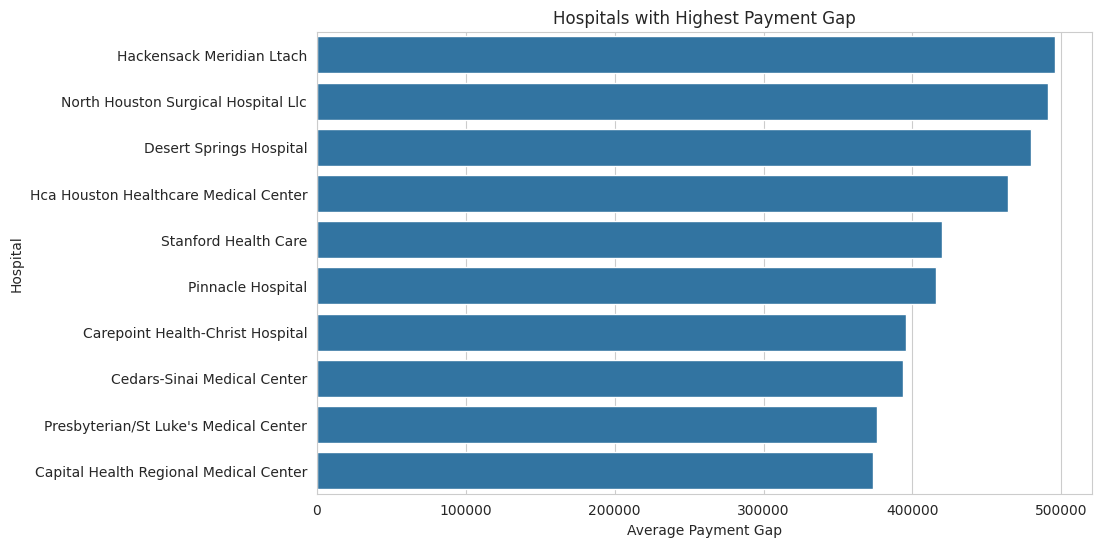

In [18]:
# 1. Top 10 High Payment Gap Hospitals
top_gap = df.groupby("hospital_name")["payment_gap"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_gap.values, y=top_gap.index)

plt.title("Hospitals with Highest Payment Gap")
plt.xlabel("Average Payment Gap")
plt.ylabel("Hospital")
plt.show()

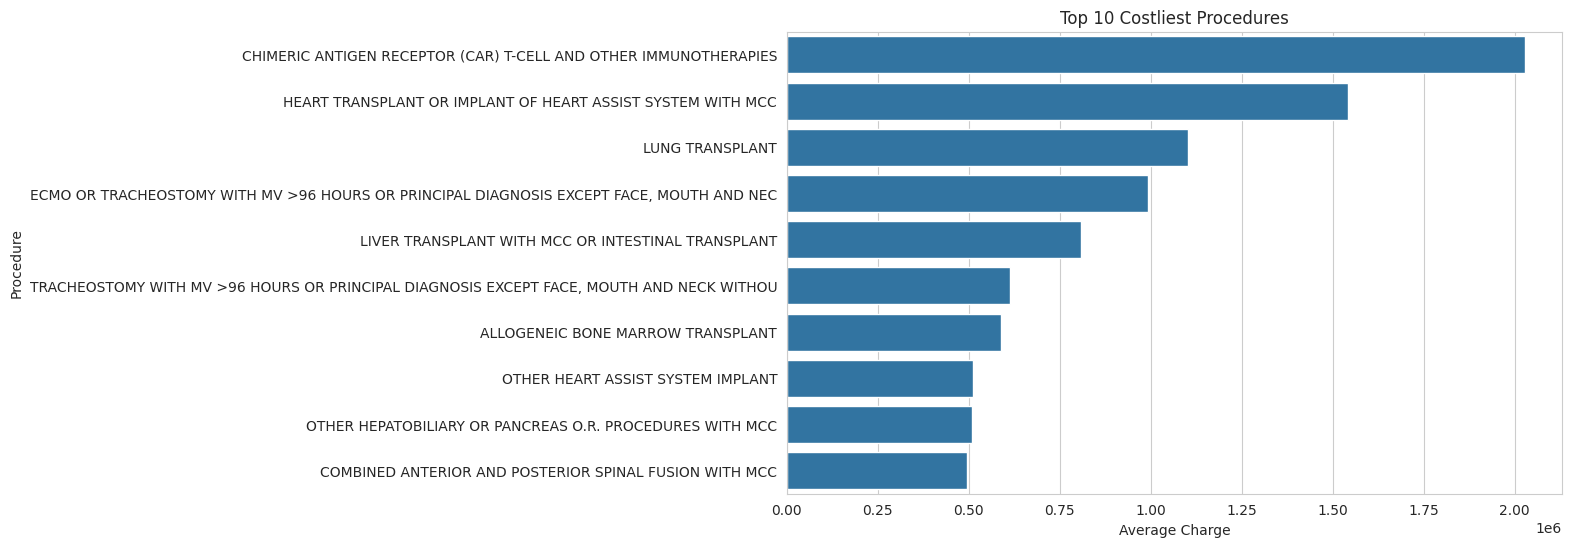

In [7]:
# 2. Procedure-wise Cost Variation

top_proc = df.groupby("procedure")["avg_charge"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_proc.values, y=top_proc.index)

plt.title("Top 10 Costliest Procedures")
plt.xlabel("Average Charge")
plt.ylabel("Procedure")
plt.show()

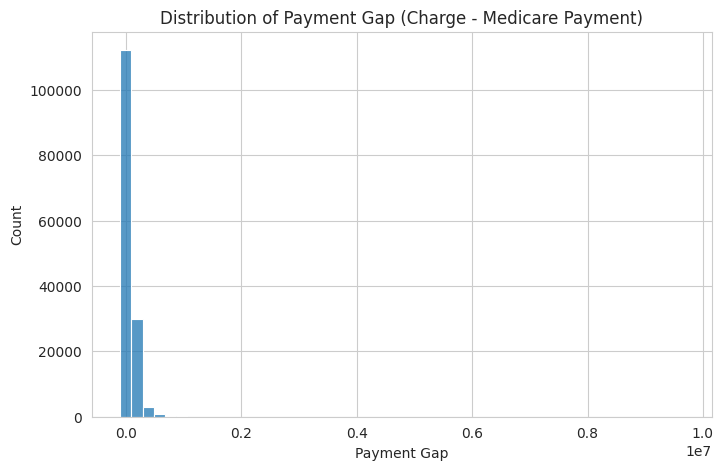

In [8]:
# 3. Payment Gap Analysis (Distribution of Hospital Charges)

df["payment_gap"] = df["avg_charge"] - df["avg_medicare_payment"]

plt.figure(figsize=(8,5))
sns.histplot(df["payment_gap"], bins=50)

plt.title("Distribution of Payment Gap (Charge - Medicare Payment)")
plt.xlabel("Payment Gap")
plt.show()

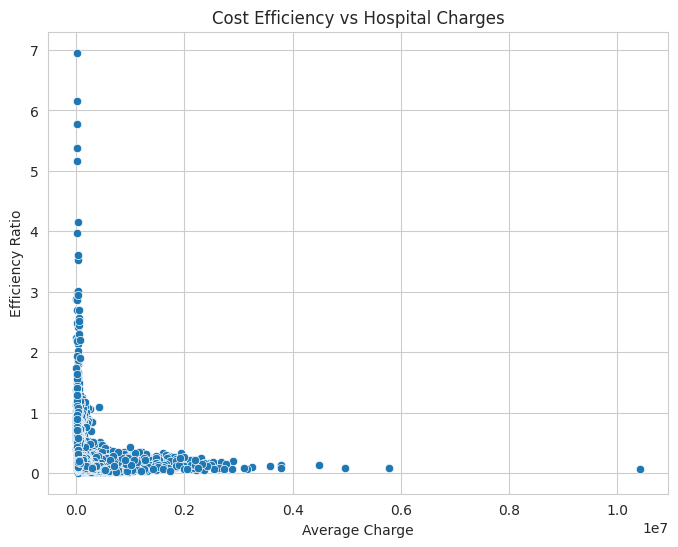

In [9]:
# 4. Cost Efficiency vs Charges

df["efficiency"] = df["avg_medicare_payment"] / df["avg_charge"]

plt.figure(figsize=(8,6))
sns.scatterplot(x="avg_charge", y="efficiency", data=df)

plt.title("Cost Efficiency vs Hospital Charges")
plt.xlabel("Average Charge")
plt.ylabel("Efficiency Ratio")
plt.show()

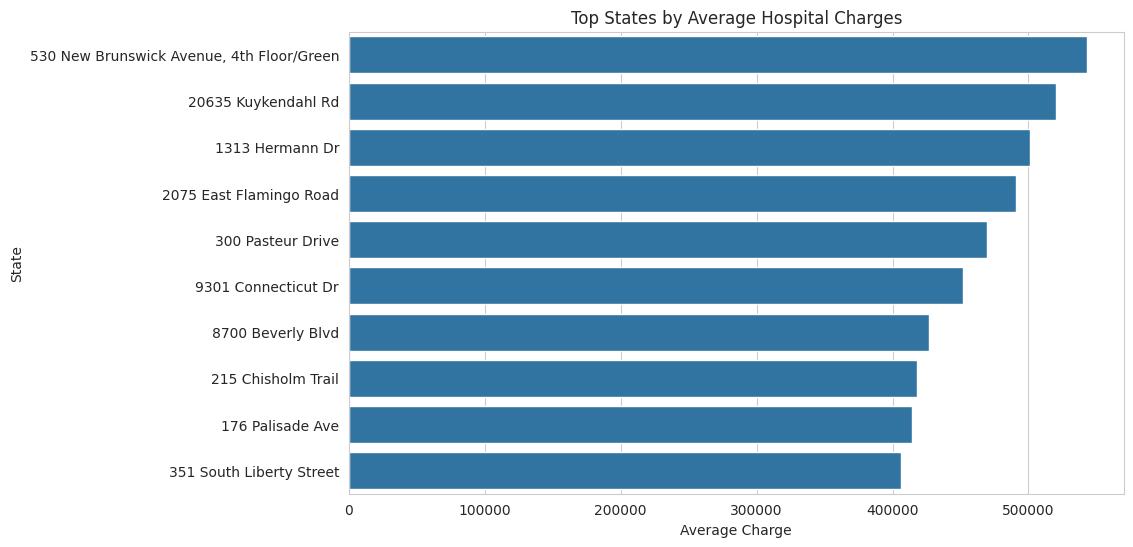

In [10]:
# 5. State-wise Cost Variation

state_cost = df.groupby("state")["avg_charge"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=state_cost.values, y=state_cost.index)

plt.title("Top States by Average Hospital Charges")
plt.xlabel("Average Charge")
plt.ylabel("State")
plt.show()

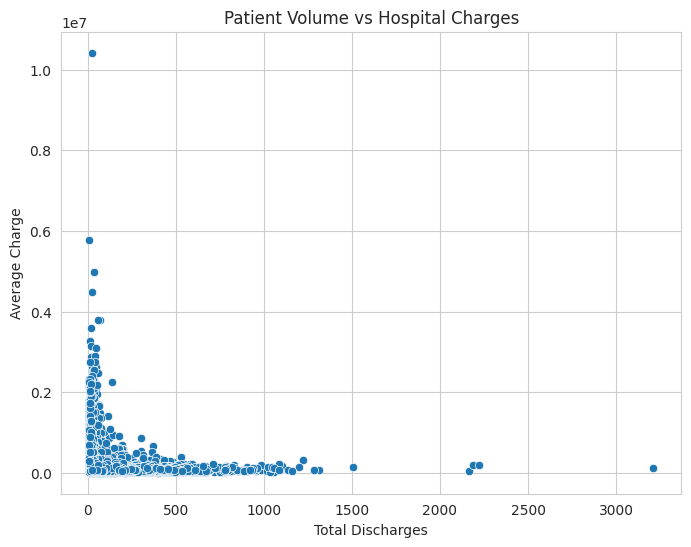

In [12]:
# 6. Discharges vs Cost

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="total_discharges",
    y="avg_charge",
    data=df
)

plt.title("Patient Volume vs Hospital Charges")
plt.xlabel("Total Discharges")
plt.ylabel("Average Charge")
plt.show()

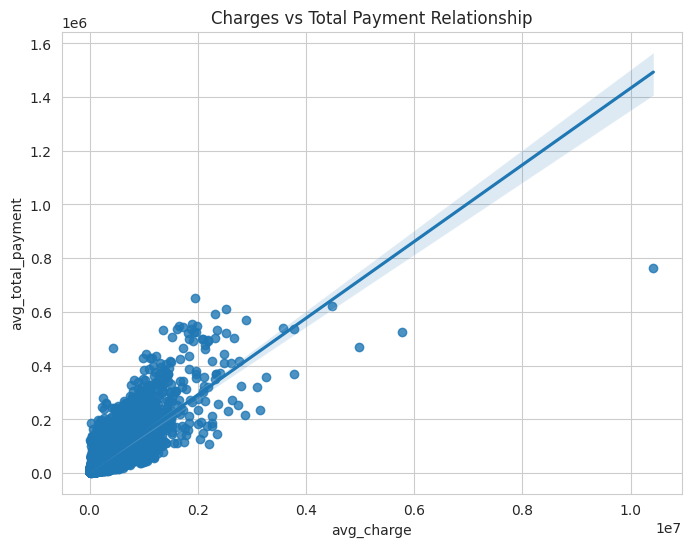

In [13]:
# 7. Cost vs Total Payment

plt.figure(figsize=(8,6))

sns.regplot(
    x="avg_charge",
    y="avg_total_payment",
    data=df
)

plt.title("Charges vs Total Payment Relationship")
plt.show()

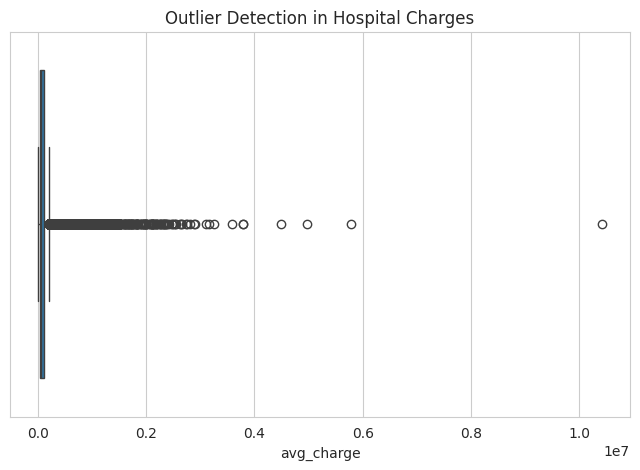

In [15]:
# 8. # Outlier Detection

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["avg_charge"]
)

plt.title("Outlier Detection in Hospital Charges")

plt.show()